# Regra de Amortização e Juros Acumulados

### Bibliotecas necessárias:

In [1]:
import holidays
import pandas as pd
import modules.dina as dina
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

### Calendário para modelagem financeira:

In [2]:
def gerar_calendario_financeiro(inicio: str, fim: str, estado: str = "SC") -> pd.DataFrame:
    """
    Gera um calendário financeiro diário com identificação de dias úteis,
    fins de semana, feriados e eventos de pagamento.

    O calendário é construído para o intervalo [inicio, fim] e inclui
    marcações úteis para aplicações financeiras, como definição do primeiro
    dia útil de cada mês como data de pagamento.

    Parameters
    ----------
    inicio : str
        Data inicial do período no formato reconhecido pelo pandas (ex: 'YYYY-MM-DD').
    fim : str
        Data final do período no formato reconhecido pelo pandas (ex: 'YYYY-MM-DD').
    estado : str, default "SC"
        Subdivisão do Brasil usada para cálculo de feriados estaduais (ex: 'SP', 'RJ', 'SC').

    Returns
    -------
    pd.DataFrame
        DataFrame contendo as seguintes colunas:
        
        - data : datetime64[ns]
            Sequência diária do período solicitado.
        - dia_semana_num : int
            Dia da semana (0=segunda-feira, 6=domingo).
        - dia_semana : str
            Nome do dia da semana.
        - fim_de_semana : bool
            Indica se a data é sábado ou domingo.
        - feriado : object
            Nome do feriado (quando aplicável), caso contrário NaN.
        - eh_feriado : bool
            Indica se a data é feriado nacional ou estadual.
        - dia_util : bool
            Indica se a data é dia útil (não fim de semana e não feriado).
        - eh_pagamento : bool
            Marca o primeiro dia útil de cada mês como data de pagamento.

    Notes
    -----
    - Os feriados são obtidos via `holidays.Brazil`.
    - A definição de "dia útil" considera apenas fim de semana e feriados,
      sem ajustes de mercado financeiro (ex: feriados bancários específicos).
    - O critério de pagamento assume o primeiro dia útil de cada mês.

    Examples
    --------
    >>> df = gerar_calendario_financeiro("2024-01-01", "2024-03-31", estado="SC")
    >>> df[df["eh_pagamento"]][["data"]]
    """

    # get dates
    datas = pd.date_range(start=inicio, end=fim, freq="D")
    df = pd.DataFrame({"data": datas})

    # get weedays
    df["dia_semana_num"] = df["data"].dt.weekday
    df["dia_semana"] = df["data"].dt.day_name()
    df["fim_de_semana"] = df["dia_semana_num"] >= 5

    # get holidays
    anos_no_periodo = list(range(datas.min().year, datas.max().year + 1))
    feriados_br = holidays.Brazil(subdiv=estado, years=anos_no_periodo)
    df["feriado"] = df["data"].dt.date.map(feriados_br)
    df["eh_feriado"] = df["feriado"].notna()

    # indendificar dias úteis
    df["dia_util"] = ~df["fim_de_semana"] & ~df["eh_feriado"]

    # marcar o primeiro dia útil de cada mês
    df["eh_pagamento"] = False
    idx_pagamentos = (
        df[df["dia_util"]]
        .groupby(df["data"].dt.to_period("M"))
        .head(1)
        .index)
    df.loc[idx_pagamentos, "eh_pagamento"] = True

    return df

In [3]:
calendario_financeiro = gerar_calendario_financeiro(inicio="2025-10-01", fim="2026-10-10", estado="SC")
display(calendario_financeiro.head(20))

,data,dia_semana_num,dia_semana,fim_de_semana,feriado,eh_feriado,dia_util,eh_pagamento
0,2025-10-01,2,Wednesday,False,NaN,False,True,True
1,2025-10-02,3,Thursday,False,NaN,False,True,False
2,2025-10-03,4,Friday,False,NaN,False,True,False
3,2025-10-04,5,Saturday,True,NaN,False,False,False
4,2025-10-05,6,Sunday,True,NaN,False,False,False
5,2025-10-06,0,Monday,False,NaN,False,True,False
6,2025-10-07,1,Tuesday,False,NaN,False,True,False
7,2025-10-08,2,Wednesday,False,NaN,False,True,False
8,2025-10-09,3,Thursday,False,NaN,False,True,False
9,2025-10-10,4,Friday,False,NaN,False,True,False


### Fluxo de Caixa da dívida:

In [4]:
def fluxo_de_caixa(aporte: float, t_cdi: float, s_fixa: float, parcela: float, calendario: pd.DataFrame, save: bool = False, data_label: str = "fluxo_de_caixa") -> pd.DataFrame:
    """
    Simula a evolução diária do saldo devedor e o fluxo de caixa de pagamentos
    com base nas taxas de juros e regras de amortização fornecidas.

    A função percorre o calendário dia a dia, acumulando os juros nos dias úteis.
    Nos dias de pagamento (1º dia útil do mês), a parcela é aplicada para liquidar
    primeiramente os juros acumulados e, o remanescente, para amortizar o principal.
    Caso a dívida seja totalmente quitada antes do fim do período, o saldo é zerado
    e o contrato é encerrado.

    Parameters
    ----------
    aporte : float
        Valor inicial do saldo devedor (principal).
    t_cdi : float
        Taxa diária do CDI em porcentagem (%).
    s_fixa : float
        Spread fixo diário em porcentagem (%).
    parcela : float
        Valor nominal da parcela mensal a ser paga nos dias de evento.
    calendario : pd.DataFrame
        DataFrame gerado pela função `gerar_calendario_financeiro`, contendo
        as colunas 'dia_util' e 'eh_pagamento'.
    save : bool, default=False
        Se True, salva o DataFrame resultante em um arquivo Excel.
    data_label : str, default="fluxo_de_caixa"
        Rótulo para nomear o arquivo salvo.

    Returns
    -------
    pd.DataFrame
        O DataFrame original acrescido das colunas de evolução financeira:
        
        - saldo_inicial : float
            Saldo devedor no início do dia.
        - juros_dia : float
            Juros gerados especificamente naquele dia.
        - juros_acumulado_pre : float
            Juros acumulados até o momento imediatamente anterior ao pagamento.
        - pagamento : float
            Fluxo de caixa de desembolso efetivo ocorrido no dia.
        - amortizacao : float
            Valor que reduziu (ou aumentou, se negativa) a dívida principal.
        - saldo_final : float
            Saldo devedor ao encerramento do dia, base para o dia seguinte.

    Notes
    -----
    - O cálculo assume capitalização diária dos juros sobre o saldo devedor do dia útil.
    - Se os juros acumulados forem maiores que a parcela no dia do pagamento,
      ocorre amortização negativa e o saldo final aumenta.
    """
    # Cria uma cópia para evitar MutationSideEffects no DataFrame original
    df = calendario.copy()

    # Inicialização das variáveis de estado (pote de acúmulo e saldo)
    saldo_devedor = float(aporte)
    juros_acumulados = 0.0

    # Listas para armazenar os resultados diários
    saldos_iniciais = []
    juros_diarios = []
    juros_acum_pre = []
    pagamentos = []
    amortizacoes = []
    saldos_finais = []

    # Loop sequencial para cálculo path-dependent
    for row in df.itertuples():
        # 1. Estado Inicial do Dia
        saldo_inicial_dia = saldo_devedor
        saldos_iniciais.append(saldo_inicial_dia)

        # 2. Capitalização Diária (O saldo devedor CRESCE a cada dia útil)
        fator = dina.fator_atualizacao(t_cdi, s_fixa, dia_util=row.dia_util)
        saldo_atualizado = dina.saldo_devedor_atual(saldo_inicial_dia, fator)
        juros_dia = dina.juro_do_dia(saldo_atualizado, saldo_inicial_dia)

        # Atualiza o pote de juros acumulados (Jacum) para fins contábeis
        juros_diarios.append(juros_dia)
        juros_acumulados += juros_dia
        juros_acum_pre.append(juros_acumulados)

        # 3. Regra de Amortização no Evento de Pagamento
        if row.eh_pagamento and saldo_atualizado > 0:
            
            # A dívida total agora é o próprio saldo_atualizado
            divida_total = saldo_atualizado

            if parcela >= divida_total:
                # Encerra o contrato
                valor_pago = divida_total
                amortizacao = divida_total - juros_acumulados # Separação contábil
                saldo_devedor = 0.0
                juros_acumulados = 0.0
            else:
                # Fluxo padrão
                valor_pago = parcela
                amortizacao = parcela - juros_acumulados # Separação contábil
                
                # AQUI: Subtraímos a parcela cheia do saldo que já contém os juros
                saldo_devedor = saldo_atualizado - parcela 
                juros_acumulados = 0.0 # Zera o pote contábil
        else:
            # Dias sem pagamento: o saldo devedor atualiza e cresce!
            valor_pago = 0.0
            amortizacao = 0.0
            saldo_devedor = saldo_atualizado

        pagamentos.append(valor_pago)
        amortizacoes.append(amortizacao)
        saldos_finais.append(saldo_devedor)

    # Agrega as novas colunas ao DataFrame estruturado
    df["saldo_inicial"] = saldos_iniciais
    df["juros_dia"] = juros_diarios
    df["juros_acumulado_pre"] = juros_acum_pre
    df["pagamento"] = pagamentos
    df["amortizacao"] = amortizacoes
    df["saldo_final"] = saldos_finais

    if save:
        df.to_excel(f"data/{data_label}.xlsx", index=False)

    return df

In [ ]:
cash_flow_df = fluxo_de_caixa(aporte=3e6, t_cdi=0.05, s_fixa=0.02, parcela=150e3, calendario=calendario_financeiro, save=True, data_label="fluxo_de_caixa")
display(cash_flow_df.head(20))

,data,dia_semana_num,dia_semana,fim_de_semana,feriado,eh_feriado,dia_util,eh_pagamento,saldo_inicial,juros_dia,juros_acumulado_pre,pagamento,amortizacao,saldo_final
0,2025-10-01,2,Wednesday,False,NaN,False,True,True,3.000000e+06,2100.300000,2100.300000,15000.0,12899.7,2.987100e+06
1,2025-10-02,3,Thursday,False,NaN,False,True,False,2.987100e+06,2091.268920,2091.268920,0.0,0.0,2.989192e+06
2,2025-10-03,4,Friday,False,NaN,False,True,False,2.989192e+06,2092.733017,4184.001937,0.0,0.0,2.991284e+06
3,2025-10-04,5,Saturday,True,NaN,False,False,False,2.991284e+06,0.000000,4184.001937,0.0,0.0,2.991284e+06
4,2025-10-05,6,Sunday,True,NaN,False,False,False,2.991284e+06,0.000000,4184.001937,0.0,0.0,2.991284e+06
5,2025-10-06,0,Monday,False,NaN,False,True,False,2.991284e+06,2094.198140,6278.200077,0.0,0.0,2.993379e+06
6,2025-10-07,1,Tuesday,False,NaN,False,True,False,2.993379e+06,2095.664288,8373.864365,0.0,0.0,2.995474e+06
7,2025-10-08,2,Wednesday,False,NaN,False,True,False,2.995474e+06,2097.131462,10470.995828,0.0,0.0,2.997571e+06
8,2025-10-09,3,Thursday,False,NaN,False,True,False,2.997571e+06,2098.599664,12569.595492,0.0,0.0,2.999670e+06
9,2025-10-10,4,Friday,False,NaN,False,True,False,2.999670e+06,2100.068894,14669.664386,0.0,0.0,3.001770e+06


### Visualizar Simulação:

In [11]:
def visualizar_fluxo_de_caixa(df: pd.DataFrame, save: bool = False, fig_label: str = "Fluxo de Caixa") -> None:
    """
    Gera visualizações gráficas para análise do fluxo de caixa, evolução do saldo
    devedor e comportamento dos juros ao longo do tempo em formato Preto e Branco
    (Escala de Cinza) com alta coerência gráfica.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contendo as colunas 'data', 'saldo_final', 
        'juros_acumulado_pre', 'amortizacao', 'pagamento'.
    """

    # Configurações de estilo para os gráficos em Preto e Branco
    sns.set_style("whitegrid")
    
    # Definindo tons de cinza/preto
    cor_preto = "#000000"
    cor_cinza_escuro = "#555555"
    cor_cinza_medio = "#888888"
    cor_cinza_claro = "#CCCCCC"
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 12)) 

    # plot 1: Evolução do Saldo Devedor
    sns.lineplot(x=df["data"], y=df["saldo_final"], 
                 color=cor_preto, linewidth=2.5, linestyle="-", ax=axes[0])
    axes[0].set_title("Evolução do Saldo Devedor ao Longo do Tempo", fontsize=20, pad=10)
    axes[0].set_ylabel("Saldo Devedor (R$)", fontsize=18)
    axes[0].set_xlabel("") 

    # plot 2: Composição do Pagamento (Juros vs Amortização)
    df_pagamentos = df[df["pagamento"] > 0].copy()
    df_pagamentos["mes_ano"] = df_pagamentos["data"].dt.strftime('%m/%Y')

    barra_total = sns.barplot(x="mes_ano", y="pagamento", data=df_pagamentos, 
                              color=cor_cinza_escuro, label="Juros Pagos (Total - Amortização)", ax=axes[1])
    barra_amort = sns.barplot(x="mes_ano", y="amortizacao", data=df_pagamentos, 
                              color=cor_cinza_claro, edgecolor=cor_preto, label="Amortização", ax=axes[1])
    num_barras = len(df_pagamentos)

    for i, patch in enumerate(axes[1].patches):
        # As primeiras N patches são do "pagamento total", as próximas N são da "amortização"
        if i >= num_barras:
            patch.set_hatch('//')  # Adiciona linhas diagonais na amortização
            patch.set_edgecolor(cor_preto)

    axes[1].set_title("Composição do Pagamento", fontsize=20, pad=10)
    axes[1].set_ylabel("Valor (R$)", fontsize=18)
    axes[1].set_xlabel("")
    axes[1].legend(fontsize=15, loc="lower left")
    axes[1].tick_params(axis='x', rotation=45) 

    #plot 3: Acúmulo Diário de Juros
    sns.lineplot(x=df["data"], y=df["juros_acumulado_pre"], 
                 color=cor_preto, linewidth=2, linestyle="-", ax=axes[2])
    axes[2].set_title("Acúmulo Diário de Juros", fontsize=20, pad=10)
    axes[2].set_ylabel("Juros Acumulados (R$)", fontsize=18)
    axes[2].set_xlabel("Data", fontsize=18)

    plt.tight_layout()
    if save:
        plt.savefig(f"figs/{fig_label}.png", dpi=300, bbox_inches='tight')
    plt.show()

    return None

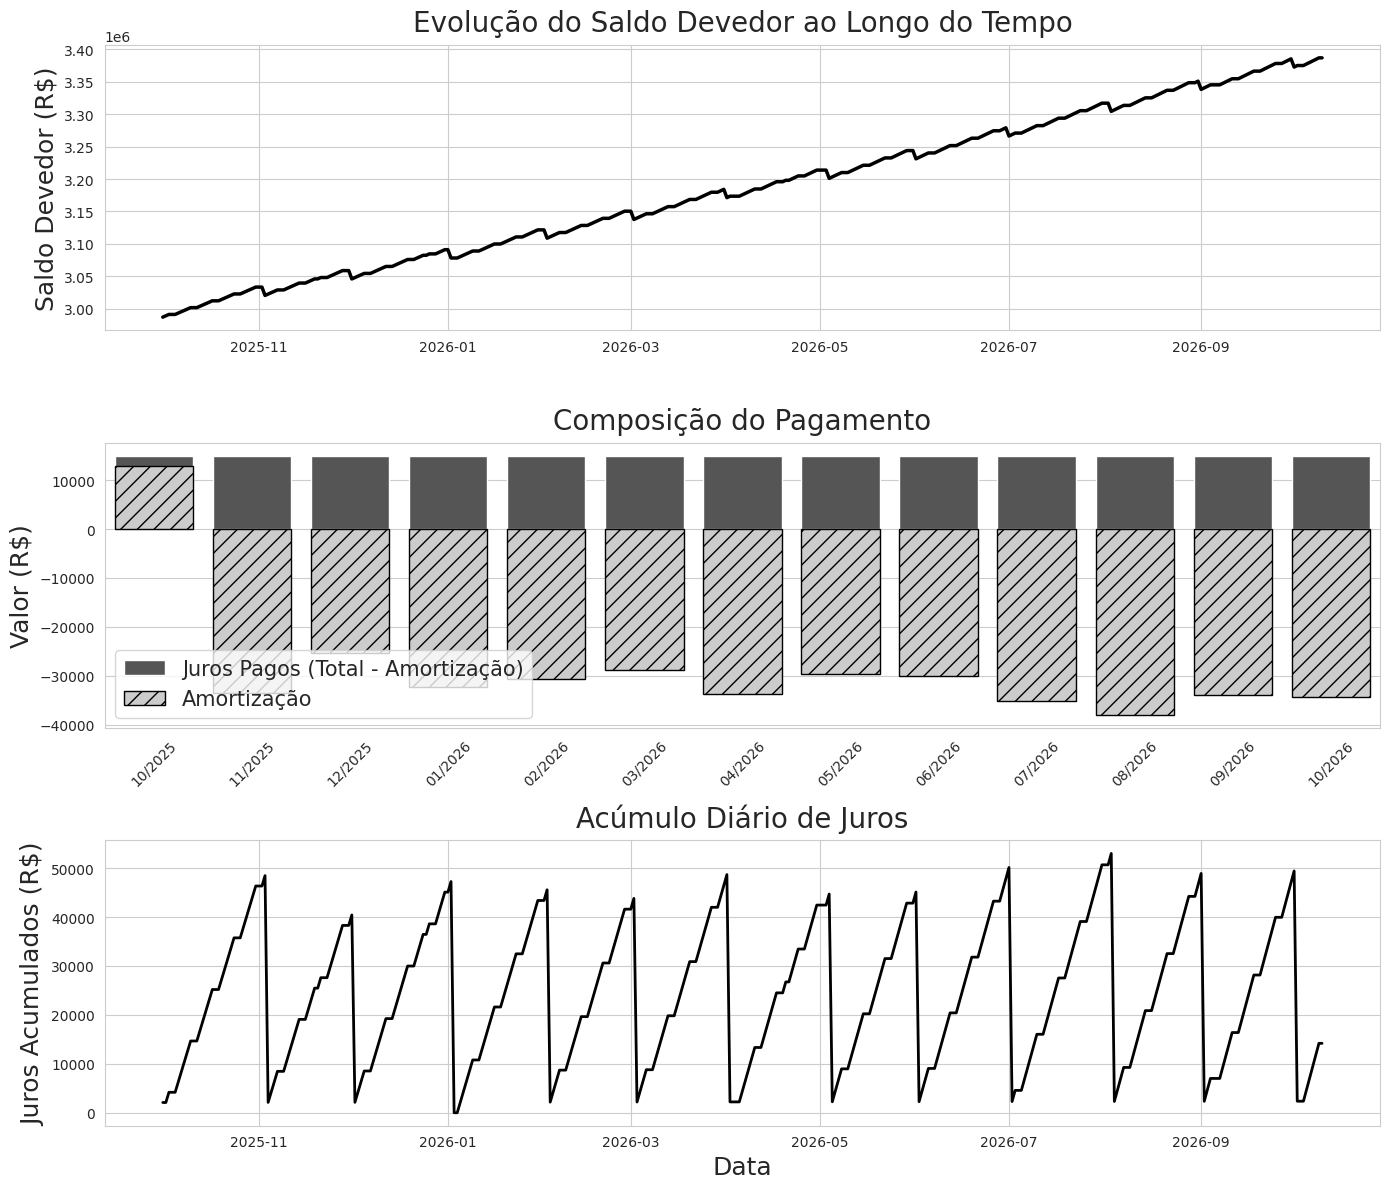

In [ ]:
visualizar_fluxo_de_caixa(cash_flow_df)#, save=True, fig_label="fluxo_de_caixa_decrescente")

### Relatório Mensal:

In [8]:
def relatorio_mensal(
    cash_flow_df: pd.DataFrame,
    formatar: bool = True,
    save: bool = False,
    data_label: str = "relatorio_mensal"
) -> pd.DataFrame:
    """
    Gera uma tabela resumida contendo apenas os eventos de pagamento
    do fluxo de caixa.

    A tabela resultante apresenta:
    - Data do pagamento;
    - Juros acumulados no período;
    - Valor amortizado do principal;
    - Saldo devedor remanescente após o pagamento.

    Parameters
    ----------
    cash_flow_df : pd.DataFrame
        DataFrame do fluxo de caixa contendo, no mínimo, as colunas:
        - 'eh_pagamento'
        - 'data'
        - 'juros_acumulado_pre'
        - 'amortizacao'
        - 'saldo_final'

    formatar : bool, default=True
        Se True, aplica formatação de data e moeda para exibição.

    save : bool, default=False
        Se True, salva o DataFrame resultante em um arquivo Excel.

    data_label : str, default="relatorio_mensal"
        Rótulo para nomear o arquivo salvo.

    Returns
    -------
    pd.DataFrame
        DataFrame resumido com os eventos de pagamento.
    """

    tabela_pagamentos = (
        cash_flow_df.loc[cash_flow_df["eh_pagamento"]]
        [
            [
                "data",
                "juros_acumulado_pre",
                "amortizacao",
                "saldo_final"
            ]
        ]
        .rename(
            columns={
                "data": "Data do Pagamento",
                "juros_acumulado_pre": "Juros Acumulados no Período",
                "amortizacao": "Amortização do Principal",
                "saldo_final": "Saldo Devedor Remanescente"
            }
        )
        .reset_index(drop=True)
    )

    if formatar:

        # formata datas
        tabela_pagamentos["Data do Pagamento"] = (
            tabela_pagamentos["Data do Pagamento"]
            .dt.strftime("%d/%m/%Y")
        )

        # formata valores monetários
        colunas_monetarias = [
            "Juros Acumulados no Período",
            "Amortização do Principal",
            "Saldo Devedor Remanescente"
        ]

        for coluna in colunas_monetarias:
            tabela_pagamentos[coluna] = (
                tabela_pagamentos[coluna]
                .map(lambda x: f"R$ {x:,.2f}")
            )

    if save:
        tabela_pagamentos.to_excel(f"data/{data_label}.xlsx", index=False)

    return tabela_pagamentos

In [9]:
relatorio = relatorio_mensal(cash_flow_df,save=True, data_label="relatorio_mensal")